# Homework 2: Predicting Fuel Efficiency

This notebook explores a vehicle dataset to predict fuel efficiency (MPG) from engineering and design features such as model year, engine displacement, horsepower, and vehicle weight.

The workflow follows a typical machine-learning pipeline: data loading, data quality checks, feature selection, train/validation split, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [10]:
# Download the dataset
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

!wget $data

--2026-10-05 17:22:54--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.02s   

2026-10-05 17:22:55 (28.0 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]



In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  str    
 2   fuel_type            10000 non-null  str    
 3   drivetrain           10000 non-null  str    
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 859.5 KB


In [4]:
# Clean string columns
strings = df.dtypes[df.dtypes =='string'].index.tolist()
for column in strings:
    df[column] = df[column].str.lower().str.replace(' ', '_').str.replace('-', '_')

In [5]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front_wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front_wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front_wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front_wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front_wheel_drive,3,2580,7,304.0,4510,17.5,31.0


In [6]:
#Select some columns for analysis
df = df[['model_year', 'engine_displacement', 'horsepower', 'vehicle_weight','fuel_efficiency_mpg']]

In [7]:
df.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


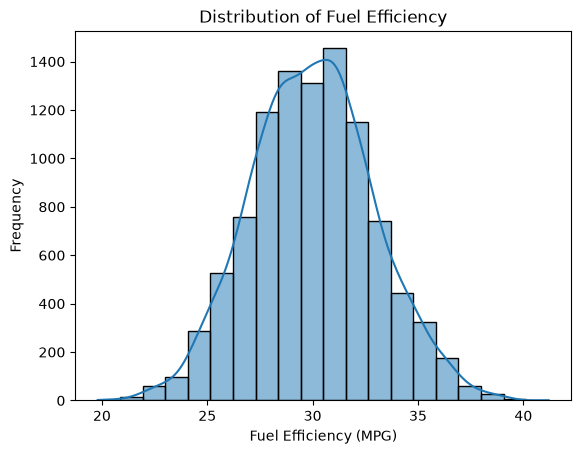

In [8]:
# plot the distribution of fuel efficiency
sns.histplot(df['fuel_efficiency_mpg'], bins=20, kde=True)
plt.title('Distribution of Fuel Efficiency')
plt.xlabel('Fuel Efficiency (MPG)')
plt.ylabel('Frequency')
plt.show()

**Q1**

In [9]:
# Check for missing values
df.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

**Q2**

In [10]:
# Display summary statistics
df.describe()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
count,10000.000000,10000.000000,9123.000000,10000.000000,10000.000000
mean,1999.549500,2268.807000,254.446016,4286.754000,29.997700
std,14.207925,183.447355,22.844613,266.212491,2.930245
min,1975.000000,1590.000000,171.000000,3320.000000,19.800000
25%,1987.000000,2150.000000,239.000000,4110.000000,28.000000
50%,2000.000000,2270.000000,254.000000,4280.000000,30.000000
75%,2012.000000,2390.000000,270.000000,4470.000000,31.900000
max,2024.000000,3110.000000,334.000000,5460.000000,41.200000


In [11]:
print(df['horsepower'].mean())

254.44601556505535


In [12]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

#shuffle the data
np.random.seed(42)
index = np.arange(n)
np.random.shuffle(index)

#split the data into train, validation, and test sets
df_train = df.iloc[index[:n_train]]
df_val = df.iloc[index[n_train:n_train + n_val]]
df_test = df.iloc[index[n_train + n_val:]]

#reset the index of the DataFrames
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

**Q3**

In [13]:
# function to train a linear regression model using the normal equation
def train_linear_regression(X, y):
    # Add a bias column to the data
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    
    # Calculate the weights 
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    
    return w[0], w[1:]  # Return bias and weights separately

In [14]:
base = ['model_year', 'engine_displacement', 'horsepower', 'vehicle_weight']

In [15]:
#function to prepare the feature matrix X
def prepare_X(df):
    #fill missing values with zero and convert to numpy arrays
    X = df[base].fillna(0).values
    return X

In [16]:
#mean of the training data
df_train_mean = df_train.mean()
#function to prepare the feature matrix X
def prepare_X_with_mean(df):
    #fill missing values with mean and convert to numpy arrays
    X = df[base].fillna(df_train_mean[base]).values
    return X

In [17]:
#rmse function
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean())

In [18]:

#prepare training data
X_train = prepare_X(df_train)
y_train = df_train['fuel_efficiency_mpg'].values

# Train the model
w0, w = train_linear_regression(X_train, y_train)

#prepare validation data
X_val = prepare_X(df_val)
y_val = df_val['fuel_efficiency_mpg'].values    

#predict on validation data
y_pred_val = w0 + X_val @ w

# Calculate and print the validation RMSE
rmse_val = rmse(y_val, y_pred_val)
print(f'Zero Validation RMSE: {round(rmse_val, 3)}')

Zero Validation RMSE: 2.205


In [19]:

#prepare training data
X_train = prepare_X_with_mean(df_train)
y_train = df_train['fuel_efficiency_mpg'].values

# Train the model
w0, w = train_linear_regression(X_train, y_train)

#prepare validation data
X_val = prepare_X_with_mean(df_val)
y_val = df_val['fuel_efficiency_mpg'].values    

#predict on validation data
y_pred_val = w0 + X_val @ w

# Calculate and print the validation RMSE
rmse_val = rmse(y_val, y_pred_val)
print(f'Mean Validation RMSE: {round(rmse_val, 3)}')

Mean Validation RMSE: 2.202


**Q4**

In [20]:
# Train a  regularized linear regression model 

def train_linear_regression_reg(X, y, r=0.001):
    # Add a bias column to the data
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    
    XTX = X.T @ X 
    XTX = XTX + r * np.eye(XTX.shape[0])

    # Calculate the weights 
    w = np.linalg.inv(XTX) @ X.T @ y
    
    return w[0], w[1:]  # Return bias and weights separately

In [21]:

r = [0, 0.01, 0.1, 1, 5, 10, 100]
for reg in r:

    #prepare training data
    X_train = prepare_X(df_train)
    y_train = df_train['fuel_efficiency_mpg'].values

    # Train the model
    w0, w = train_linear_regression_reg(X_train, y_train, r=reg)

    #prepare validation data
    X_val = prepare_X(df_val)
    y_val = df_val['fuel_efficiency_mpg'].values  

    #predict on validation data
    y_pred_val = w0 + X_val @ w
    
    # Calculate and print the validation RMSE
    rmse_val = rmse(y_val, y_pred_val)
    print(f'Validation RMSE for reg={reg}: {round(rmse_val, 4)}')

Validation RMSE for reg=0: 2.2053
Validation RMSE for reg=0.01: 2.2058
Validation RMSE for reg=0.1: 2.2241
Validation RMSE for reg=1: 2.3492
Validation RMSE for reg=5: 2.4094
Validation RMSE for reg=10: 2.4195
Validation RMSE for reg=100: 2.4292


**Q5**

In [22]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

total_rmse = []
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
for reproducibility in seed:
    np.random.seed(reproducibility)
    #shuffle the data
    index = np.arange(n)
    np.random.shuffle(index)

    
    #split the data into train, validation, and test sets
    df_train = df.iloc[index[:n_train]]
    df_val = df.iloc[index[n_train:n_train + n_val]]
    df_test = df.iloc[index[n_train + n_val:]]


    #reset the index of the DataFrames
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    #prepare training data
    X_train = prepare_X(df_train)
    y_train = df_train['fuel_efficiency_mpg'].values
    # Train the model
    w0, w = train_linear_regression(X_train, y_train)

    #prepare validation data
    X_val = prepare_X(df_val)
    y_val = df_val['fuel_efficiency_mpg'].values
    #predict on validation data
    y_pred_val = w0 + X_val @ w

    # Calculate and print the validation RMSE
    rmse_val = rmse(y_val, y_pred_val)
    print(f'Validation RMSE for seed={reproducibility}: {round(rmse_val, 3)}')

    total_rmse.append(rmse_val)

print(f'Standard deviation of validation RMSE: {round(np.std(total_rmse), 3)}')

Validation RMSE for seed=0: 2.239
Validation RMSE for seed=1: 2.202
Validation RMSE for seed=2: 2.163
Validation RMSE for seed=3: 2.204
Validation RMSE for seed=4: 2.202
Validation RMSE for seed=5: 2.246
Validation RMSE for seed=6: 2.27
Validation RMSE for seed=7: 2.191
Validation RMSE for seed=8: 2.217
Validation RMSE for seed=9: 2.207
Standard deviation of validation RMSE: 0.029


**Q6**

In [23]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

#shuffle the data
np.random.seed(9)
index = np.arange(n)
np.random.shuffle(index)

#split the data into train, validation, and test sets
df_train = df.iloc[index[:n_train]]
df_val = df.iloc[index[n_train:n_train + n_val]]
df_test = df.iloc[index[n_train + n_val:]]

#reset the index of the DataFrames
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

#combine the train and validation sets
df_train = pd.concat([df_train, df_val], ignore_index=True)
X_train = prepare_X(df_train)
y_train = df_train['fuel_efficiency_mpg'].values   

# Train the model
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)       

#prepare test data
X_test = prepare_X(df_test)
y_test = df_test['fuel_efficiency_mpg'].values
#predict on test data
y_pred_test = w0 + X_test @ w

# Calculate and print the test RMSE
rmse_test = rmse(y_test, y_pred_test)
print(f'Test RMSE: {round(rmse_test, 3)}')

Test RMSE: 2.236
